In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats # used to calculate z-scores to investigate outliers

import warnings
warnings.filterwarnings("ignore") # ignores warnings

In [ ]:
pd.options.display.float_format = "{:.2f}".format

In [ ]:
data = pd.read_csv("ecomdata.csv", encoding = "ISO-8859-1")

In [ ]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.00,United Kingdom


In [ ]:
data.shape

(541909, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
data[data.isin(["NA","NaN","na","N/A","n/a","missing","MISSING","no data","nodata","","?","??","???","????","?????"]).any(axis=1)].shape

(58, 8)

In [ ]:
data[data.isin(["NA","NaN","na","N/A","n/a","missing","MISSING","no data","nodata","","?","??","???","????","?????"]).any(axis=1)].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,12-03-2010 16:50,0.00,NaN,United Kingdom
21518,538090,20956,?,-723,12-09-2010 14:48,0.00,NaN,United Kingdom
38261,539494,21479,?,752,12/20/2010 10:36,0.00,NaN,United Kingdom
43662,540100,22837,?,-106,01-04-2011 16:53,0.00,NaN,United Kingdom
50806,540558,21258,?,-29,01-10-2011 10:04,0.00,NaN,United Kingdom
51673,540651,82599,?,-290,01-10-2011 15:00,0.00,NaN,United Kingdom
68920,541882,48185,?,-57,1/24/2011 10:54,0.00,NaN,United Kingdom
78235,542861,47591B,?,-207,02-01-2011 11:47,0.00,NaN,United Kingdom
94765,544410,84997C,?,-741,2/18/2011 13:54,0.00,NaN,United Kingdom
97643,544649,21621,?,-400,2/22/2011 12:37,0.00,NaN,United Kingdom


In [ ]:
data["UnitPrice"].describe()

count   541909.00
mean         4.61
std         96.76
min     -11062.06
25%          1.25
50%          2.08
75%          4.13
max      38970.00
Name: UnitPrice, dtype: float64

In [ ]:
data[data["UnitPrice"]==0].shape

(2515, 8)

In [ ]:
data[data["UnitPrice"]==0]["Description"].nunique(dropna=False)

377

In [ ]:
data[data["UnitPrice"]==0]["Description"].unique()[0:20]

array([nan, 'amazon', '?', 'ROUND CAKE TIN VINTAGE GREEN', 'check',
       'damages', 'CREAM SWEETHEART LETTER RACK',
       'ZINC WILLIE WINKIE  CANDLE STICK', 'BOX OF 24 COCKTAIL PARASOLS',
       'DOORMAT ENGLISH ROSE ', 'DOORMAT 3 SMILEY CATS',
       'GREEN REGENCY TEACUP AND SAUCER', 'FRENCH BLUE METAL DOOR SIGN 7',
       'FRENCH BLUE METAL DOOR SIGN 5', 'FRENCH BLUE METAL DOOR SIGN 6',
       'FRENCH BLUE METAL DOOR SIGN 4', 'FRENCH BLUE METAL DOOR SIGN No',
       'FRENCH BLUE METAL DOOR SIGN 8', 'FRENCH BLUE METAL DOOR SIGN 1',
       'RED KITCHEN SCALES'], dtype=object)

In [ ]:
data = data[data["UnitPrice"]!=0]

In [ ]:
data.shape

(539394, 8)

In [ ]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132605
Country             0
dtype: int64

In [ ]:
data[data["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,08-12-2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,08-12-2011 14:52,-11062.06,NaN,United Kingdom


In [ ]:
data[data["Description"].str.lower().str.contains("adjust")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,08-12-2011 14:50,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,08-12-2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,08-12-2011 14:52,-11062.06,NaN,United Kingdom


In [ ]:
data = data[data["Description"].str.lower().str.contains("adjust")==False]

In [ ]:
data["Description"].nunique(dropna=False)

4041

In [ ]:
data["Description"] = data["Description"].str.strip()

In [ ]:
data["Description"].nunique(dropna=False)

4030

In [ ]:
data[data["Description"].str.contains("PAPER CRAFT")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12-09-2011 09:15,2.08,16446.00,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12-09-2011 09:27,2.08,16446.00,United Kingdom


In [ ]:
data[data["InvoiceNo"].str.startswith("C")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12-01-2010 09:41,27.50,14527.00,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12-01-2010 09:49,4.65,15311.00,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12-01-2010 10:24,1.65,17548.00,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12-01-2010 10:24,0.29,17548.00,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12-01-2010 10:24,0.29,17548.00,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12-01-2010 10:24,0.29,17548.00,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12-01-2010 10:24,3.45,17548.00,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12-01-2010 10:24,1.65,17548.00,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12-01-2010 10:24,1.65,17548.00,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12-01-2010 12:38,4.25,17897.00,United Kingdom


In [ ]:
credit_descr = pd.Series(data[data["InvoiceNo"].str.startswith("C")]["Description"].unique())
credit_descr

0                                 Discount
1          SET OF 3 COLOURED  FLYING DUCKS
2            PLASTERS IN TIN CIRCUS PARADE
3          PACK OF 12 PINK PAISLEY TISSUES
4          PACK OF 12 BLUE PAISLEY TISSUES
                       ...                
1966                ELEPHANT BIRTHDAY CARD
1967              AFGHAN SLIPPER SOCK PAIR
1968    SMALL SQUARE CUT GLASS CANDLESTICK
1969          HOUSE SHAPE PENCIL SHARPENER
1970           PAPER CRAFT , LITTLE BIRDIE
Length: 1971, dtype: object

In [ ]:
credit_descr[credit_descr.str.isupper()==False]

0                                 Discount
57           NUMBER TILE COTTAGE GARDEN No
133                           Bank Charges
147                                 Manual
320         FRENCH BLUE METAL DOOR SIGN No
626                BAG 125g SWIRLY MARBLES
767                BAG 500g SWIRLY MARBLES
800         FOLK ART GREETING CARD,pack/12
1229    3 TRADITIONAl BISCUIT CUTTERS  SET
1275          POLYESTER FILLER PAD 40x40cm
1304                     Next Day Carriage
1305          POLYESTER FILLER PAD 45x45cm
1355               BAG 250g SWIRLY MARBLES
1511                       CRUK Commission
dtype: object

In [ ]:
data = data[data["Description"].isin(["Bank Charges","CRUK Commission"])==False]

In [ ]:
credit_descr[credit_descr.str.len()<15]

0             Discount
93          BUTTON BOX
127            POSTAGE
133       Bank Charges
134            SAMPLES
136         AMAZON FEE
147             Manual
183     RETROSPOT LAMP
188          BINGO SET
196     RETRO MOD TRAY
266     JUMBO BAG TOYS
321      POTTERING MUG
455           CARRIAGE
471      CHILLI LIGHTS
493      PINK DOG BOWL
497      FIRST AID TIN
502     JUMBO BAG OWLS
572        FROG CANDLE
685     DOTCOM POSTAGE
746     MIRROR CORNICE
811      PARTY BUNTING
885     FUNKY DIVA PEN
950     DOORMAT HEARTS
1127    SPOTTY BUNTING
1181       WICKER STAR
1217    KEY FOB , SHED
1247    POPCORN HOLDER
1385      TOYBOX  WRAP
1392    SANDALWOOD FAN
1401    GLAMOROUS  MUG
1483    PACKING CHARGE
1519    SHOE SHINE BOX
1731      WRAP COWBOYS
1848    MILK MAIDS MUG
dtype: object

In [ ]:
data = data[data["Description"].isin(["AMAZON FEE","SAMPLES","POSTAGE","PACKING CHARGE"])==False]

In [ ]:
list_dotcom = data[data["Description"].replace({np.nan:""}).str.lower().str.contains("dotcom",regex=True)]["Description"].unique().tolist()
list_dotcom

['DOTCOM POSTAGE',
 'MUG , DOTCOMGIFTSHOP.COM',
 'Dotcomgiftshop Gift Voucher £40.00',
 'Dotcomgiftshop Gift Voucher £50.00',
 'Dotcomgiftshop Gift Voucher £30.00',
 'Dotcomgiftshop Gift Voucher £20.00',
 'DOTCOMGIFTSHOP TEA TOWEL',
 'Dotcomgiftshop Gift Voucher £10.00',
 'Dotcomgiftshop Gift Voucher £100.00']

In [ ]:
data["Description"] = data["Description"].replace(list_dotcom,"DOTCOM")

In [ ]:
data["Description"].nunique()#check no. of unique descriptions

4016

In [ ]:
data["StockCode"].nunique()

3931

In [ ]:
num_descriptions = data.groupby("StockCode")["Description"].nunique().sort_values(ascending = False)
num_descriptions

StockCode
23196     4
23236     4
17107D    3
22937     3
22776     3
         ..
15056n    1
15056p    1
15058A    1
15058B    1
90214K    1
Name: Description, Length: 3931, dtype: int64

In [ ]:
num_descriptions.value_counts()

Description
1    3714
2     200
3      15
4       2
Name: count, dtype: int64

In [ ]:
groups = data.groupby("StockCode")["Description"].unique()
groups

StockCode
10002            [INFLATABLE POLITICAL GLOBE]
10080              [GROOVY CACTUS INFLATABLE]
10120                          [DOGGY RUBBER]
10123C                 [HEARTS WRAPPING TAPE]
10124A          [SPOTS ON RED BOOKCOVER TAPE]
                            ...              
gift_0001_20                         [DOTCOM]
gift_0001_30                         [DOTCOM]
gift_0001_40                         [DOTCOM]
gift_0001_50                         [DOTCOM]
m                                    [Manual]
Name: Description, Length: 3931, dtype: object

In [ ]:
groups[groups.str.len()>1]

StockCode
16156L                      [WRAP, CAROUSEL, WRAP CAROUSEL]
17107D    [FLOWER FAIRY,5 SUMMER B'DRAW LINERS, FLOWER F...
20622               [VIPPASSPORT COVER, VIP PASSPORT COVER]
20725       [LUNCH BAG RED RETROSPOT, LUNCH BAG RED SPOTTY]
20914     [SET/5 RED RETROSPOT LID GLASS BOWLS, SET/5 RE...
                                ...                        
85184C    [S/4 VALENTINE DECOUPAGE HEART BOX, SET 4 VALE...
85185B    [PINK HORSE SOCK PUPPET, PINK HORSE SOCK PUPPE...
90014A    [SILVER/MOP ORBIT NECKLACE, SILVER M.O.P. ORBI...
90014B    [GOLD M PEARL  ORBIT NECKLACE, GOLD M.O.P. ORB...
90014C    [SILVER/BLACK ORBIT NECKLACE, SILVER AND BLACK...
Name: Description, Length: 217, dtype: object

In [ ]:
dictionary = {}
for index, group in groups.items():
    dictionary[index] = group[0]

In [ ]:
list(dictionary.items())[0:10]

[('10002', 'INFLATABLE POLITICAL GLOBE'),
 ('10080', 'GROOVY CACTUS INFLATABLE'),
 ('10120', 'DOGGY RUBBER'),
 ('10123C', 'HEARTS WRAPPING TAPE'),
 ('10124A', 'SPOTS ON RED BOOKCOVER TAPE'),
 ('10124G', 'ARMY CAMO BOOKCOVER TAPE'),
 ('10125', 'MINI FUNKY DESIGN TAPES'),
 ('10133', 'COLOURING PENCILS BROWN TUBE'),
 ('10135', 'COLOURING PENCILS BROWN TUBE'),
 ('11001', 'ASSTD DESIGN RACING CAR PEN')]

In [ ]:
descriptions = pd.DataFrame()

In [ ]:
descriptions["StockCode"] = list(dictionary.keys())

In [ ]:
descriptions["Unique_Description"] = list(dictionary.values())

In [ ]:
descriptions.head()

,StockCode,Unique_Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE


In [ ]:
data = data.merge(descriptions, on = "StockCode", how = "inner")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Unique_Description
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.00,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.00,United Kingdom,WHITE METAL LANTERN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.00,United Kingdom,CREAM CUPID HEARTS COAT HANGER
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.00,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.00,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.


In [ ]:
data["Description"].nunique()

4016

In [ ]:
data["Unique_Description"].nunique()

3788

In [ ]:
data["Description"]=data["Unique_Description"]
data=data.drop("Unique_Description",axis=1)

In [ ]:
data["StockCode"].nunique()

3931

In [ ]:
descr_counts = pd.Series(descriptions["Unique_Description"].value_counts())
descr_counts[descr_counts>1]

Unique_Description
DOTCOM                            9
METAL SIGN,CUPCAKE SINGLE HOOK    6
SET OF 4 FAIRY CAKE PLACEMATS     4
COLUMBIAN CANDLE ROUND            3
FRENCH LATTICE CUSHION COVER      2
                                 ..
Manual                            2
EDWARDIAN PARASOL BLACK           2
EDWARDIAN PARASOL NATURAL         2
EDWARDIAN PARASOL PINK            2
FAIRY CAKE DESIGN UMBRELLA        2
Name: count, Length: 129, dtype: int64

In [ ]:
descriptions[descriptions["Unique_Description"].str.contains("METAL SIGN,CUPCAKE")]

,StockCode,Unique_Description
2889,82613A,"METAL SIGN,CUPCAKE SINGLE HOOK"
2890,82613B,"METAL SIGN,CUPCAKE SINGLE HOOK"
2891,82613C,"METAL SIGN,CUPCAKE SINGLE HOOK"
2893,82613a,"METAL SIGN,CUPCAKE SINGLE HOOK"
2894,82613b,"METAL SIGN,CUPCAKE SINGLE HOOK"
2895,82613c,"METAL SIGN,CUPCAKE SINGLE HOOK"


In [ ]:
descriptions[descriptions["Unique_Description"].str.contains("COLUMBIAN CANDLE ROUND")]

,StockCode,Unique_Description
2751,72127,COLUMBIAN CANDLE ROUND
2752,72128,COLUMBIAN CANDLE ROUND
2753,72130,COLUMBIAN CANDLE ROUND


In [ ]:
#outliers
data["ItemTotal"] = data["Quantity"]*data["UnitPrice"]

In [ ]:
data.shape

(537973, 9)

In [ ]:
data.describe()

,Quantity,UnitPrice,CustomerID,ItemTotal
count,537973.00,537973.00,405549.00,537973.00
mean,9.87,4.08,15294.90,18.46
std,215.70,61.50,1710.29,372.65
min,-80995.00,0.00,12346.00,-168469.60
25%,1.00,1.25,13969.00,3.75
50%,3.00,2.08,15159.00,9.84
75%,10.00,4.13,16794.00,17.40
max,80995.00,38970.00,18287.00,168469.60


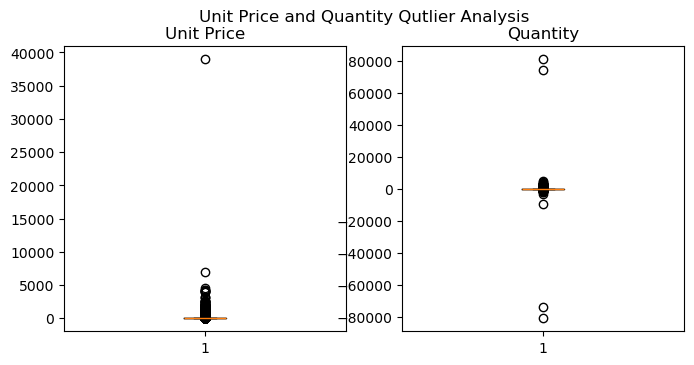

In [ ]:
plt.style.use("default")
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (8,3.7))

ax1.boxplot(data["UnitPrice"])
ax1.set_title("Unit Price")
ax2.boxplot(data["Quantity"])
ax2.set_title("Quantity")
fig.suptitle("Unit Price and Quantity Qutlier Analysis")
plt.show()

In [ ]:
z = np.abs(stats.zscore(data["Quantity"]))
len(np.where(z>3)[0])

260

In [ ]:
z = np.abs(stats.zscore(data["UnitPrice"]))
len(np.where(z>3)[0])

546

In [ ]:
data[np.abs(data["Quantity"])>1000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ItemTotal
4274,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,12-02-2010 14:23,0.03,15838.00,United Kingdom,-280.80
4834,536809,84950,ASSORTED COLOUR T-LIGHT HOLDER,1824,12-02-2010 16:48,0.55,15299.00,United Kingdom,1003.20
4929,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,12-02-2010 17:38,0.18,16754.00,United Kingdom,518.40
4930,536830,21915,RED HARMONICA IN BOX,1400,12-02-2010 17:38,1.06,16754.00,United Kingdom,1484.00
6345,536890,17084R,ASSORTED INCENSE PACK,1440,12-03-2010 11:48,0.16,14156.00,EIRE,230.40
...,...,...,...,...,...,...,...,...,...
531051,581175,23084,RABBIT NIGHT LIGHT,1440,12-07-2011 15:16,1.79,14646.00,Netherlands,2577.60
536139,581458,22197,SMALL POPCORN HOLDER,1500,12-08-2011 18:45,0.72,17949.00,United Kingdom,1080.00
536140,581459,22197,SMALL POPCORN HOLDER,1200,12-08-2011 18:46,0.72,17949.00,United Kingdom,864.00
536490,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12-09-2011 09:15,2.08,16446.00,United Kingdom,168469.60


In [ ]:
data[np.abs(data["Quantity"])>10000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ItemTotal
61163,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.00,United Kingdom,77183.60
61168,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.00,United Kingdom,-77183.60
536490,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12-09-2011 09:15,2.08,16446.00,United Kingdom,168469.60
536491,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12-09-2011 09:27,2.08,16446.00,United Kingdom,-168469.60


In [ ]:
data = data[np.abs(data["Quantity"])<10000]

In [ ]:
data[np.abs(data["Quantity"])>2000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ItemTotal
4274,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,12-02-2010 14:23,0.03,15838.00,United Kingdom,-280.80
4929,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,12-02-2010 17:38,0.18,16754.00,United Kingdom,518.40
32424,539101,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400,12/16/2010 10:35,0.94,16029.00,United Kingdom,2256.00
52283,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,01-11-2011 12:55,2.10,15749.00,United Kingdom,6539.40
80134,543057,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2592,02-03-2011 10:50,0.21,16333.00,United Kingdom,544.32
86977,543669,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400,02-11-2011 11:22,0.94,16029.00,United Kingdom,2256.00
91100,544152,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2400,2/16/2011 12:10,0.06,14609.00,United Kingdom,144.00
96702,544612,22053,EMPIRE DESIGN ROSETTE,3906,2/22/2011 10:43,0.82,18087.00,United Kingdom,3202.92
124321,547037,21967,PACK OF 12 SKULL TISSUES,2160,3/20/2011 10:37,0.25,14101.00,United Kingdom,540.00
158777,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,4/18/2011 13:08,2.10,15749.00,United Kingdom,-6539.40


In [ ]:
z = np.abs(stats.zscore(data["UnitPrice"]))
data[z>3].sort_values(by = "UnitPrice", ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ItemTotal
220733,C556445,M,Manual,-1,06-10-2011 15:31,38970.00,15098.00,United Kingdom,-38970.00
171869,C551699,M,Manual,-1,05-03-2011 14:12,6930.00,16029.00,United Kingdom,-6930.00
295256,562955,DOT,DOTCOM,1,08-11-2011 10:14,4505.17,NaN,United Kingdom,4505.17
265783,C560372,M,Manual,-1,7/18/2011 12:26,4287.63,17448.00,United Kingdom,-4287.63
265784,560373,M,Manual,1,7/18/2011 12:30,4287.63,NaN,United Kingdom,4287.63
...,...,...,...,...,...,...,...,...,...
78361,542906,DOT,DOTCOM,1,02-01-2011 15:12,189.59,NaN,United Kingdom,189.59
40575,539744,DOT,DOTCOM,1,12/21/2010 15:21,189.57,NaN,United Kingdom,189.57
176433,C552203,M,Manual,-1,05-06-2011 14:56,189.44,NaN,United Kingdom,-189.44
420004,573137,DOT,DOTCOM,1,10/27/2011 17:15,188.89,NaN,United Kingdom,188.89


In [ ]:
data[z>3]["Description"].unique()

array(['DOTCOM', 'VINTAGE RED KITCHEN CABINET', 'Manual', 'Discount',
       'LOVE SEAT ANTIQUE WHITE METAL', 'VINTAGE BLUE KITCHEN CABINET',
       'PICNIC BASKET WICKER SMALL'], dtype=object)

In [ ]:
data[data["Description"].str.contains("PICNIC BASKET")].sort_values(by="UnitPrice", ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ItemTotal
220734,556446,22502,PICNIC BASKET WICKER SMALL,1,06-10-2011 15:33,649.50,15098.00,United Kingdom,649.50
220732,556444,22502,PICNIC BASKET WICKER SMALL,60,06-10-2011 15:28,649.50,15098.00,United Kingdom,38970.00
2724,536592,22501,PICNIC BASKET WICKER LARGE,2,12-01-2010 17:06,21.23,NaN,United Kingdom,42.46
15775,537642,22501,PICNIC BASKET WICKER LARGE,1,12-07-2010 15:33,21.23,NaN,United Kingdom,21.23
27379,538566,22501,PICNIC BASKET WICKER LARGE,1,12/13/2010 11:21,21.23,NaN,United Kingdom,21.23
...,...,...,...,...,...,...,...,...,...
68536,541932,22502,PICNIC BASKET WICKER SMALL,16,1/24/2011 11:39,4.95,14439.00,Greece,79.20
71491,542222,22502,PICNIC BASKET WICKER SMALL,48,1/26/2011 12:42,4.95,14616.00,United Kingdom,237.60
32305,539088,22502,PICNIC BASKET WICKER SMALL,16,12/16/2010 9:45,4.95,13093.00,United Kingdom,79.20
211256,555520,22501,PICNIC BASKET WICKER LARGE,1,06-05-2011 11:14,3.00,15038.00,United Kingdom,3.00


In [ ]:
data = data.drop(data.index[[88771,88772,297271]])

In [ ]:
data.to_csv("online_retail.csv", index = False)